# **Diabetes Prediction using Decision Tree Regressor**

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

np.random.seed(10)
plt.rcParams['figure.figsize'] = (8, 6)
%matplotlib inline

# **1. Load the Diabetes Dataset**

In [2]:
diabetes = load_diabetes()

print("Keys available:", list(diabetes.keys()))
print("\nData shape:", diabetes.data.shape)
print("\nDescription (first 600 chars):\n", diabetes.DESCR[:600])

Keys available: ['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module']

Data shape: (442, 10)

Description (first 600 chars):
 .. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years


In [3]:
df_diabetes = pd.DataFrame(
    diabetes.data,
    columns=['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
)
df_diabetes['target'] = diabetes.target

df_diabetes.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


The **target column** represents the **disease progression measured one year after the patient's baseline examination**. Since the target is a **continuous numerical value**, the goal is to predict a number rather than a category, making this a **regression problem** rather than a classification problem.

> **Note:** The feature values in `diabetes.data` are already **standardized by Scikit-learn**. Each feature has been **mean-centered and scaled**, which is why variables such as `age`, `bmi`, and `bp` appear as small decimal values instead of their original units. This preprocessing is built into the dataset itself, so **no additional feature scaling is required** before training most machine learning models on this dataset.

In [4]:
df_diabetes.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [5]:
print("Missing values:")
print(df_diabetes.isnull().sum().sum(), "total missing values")

Missing values:
0 total missing values


# **2. Independent (X) and Dependent (y) Features**

In [5]:
X = df_diabetes.drop(columns=['target'])
y = df_diabetes['target']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (442, 10)
y shape: (442,)


# **3. Train/Test Split**

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=10
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
X_train.head()

X_train shape: (309, 10)
X_test shape : (133, 10)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
249,-0.012780,-0.044642,0.060618,0.052858,0.047965,0.029375,-0.017629,0.034309,0.070207,0.007207
389,-0.005515,0.050680,0.001339,-0.084856,-0.011201,-0.016658,0.048640,-0.039493,-0.041176,-0.088062
121,0.063504,-0.044642,0.017506,0.021872,0.008063,0.021546,-0.036038,0.034309,0.019907,0.011349
195,0.027178,0.050680,0.025051,0.014987,0.025950,0.048477,-0.039719,0.034309,0.007838,0.023775
69,0.016281,-0.044642,-0.046085,-0.005670,-0.075870,-0.061438,-0.013948,-0.039493,-0.051404,0.019633


## **4. Correlation Analysis**

In [7]:
correlation = X_train.corr()
correlation

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
age,1.000000,0.197408,0.198359,0.394903,0.238375,0.192920,-0.128403,0.227110,0.314151,0.351570
sex,0.197408,1.000000,0.108261,0.221914,0.057674,0.180315,-0.379464,0.324882,0.150956,0.193322
bmi,0.198359,0.108261,1.000000,0.356324,0.226047,0.248146,-0.395021,0.412826,0.435505,0.358273
bp,0.394903,0.221914,0.356324,1.000000,0.238295,0.165632,-0.192505,0.249141,0.420236,0.368882
s1,0.238375,0.057674,0.226047,0.238295,1.000000,0.872781,0.006313,0.559626,0.566312,0.356280
s2,0.192920,0.180315,0.248146,0.165632,0.872781,1.000000,-0.265114,0.684840,0.325759,0.315890
s3,-0.128403,-0.379464,-0.395021,-0.192505,0.006313,-0.265114,1.000000,-0.754616,-0.370523,-0.297055
s4,0.227110,0.324882,0.412826,0.249141,0.559626,0.684840,-0.754616,1.000000,0.609983,0.436311
s5,0.314151,0.150956,0.435505,0.420236,0.566312,0.325759,-0.370523,0.609983,1.000000,0.490970
s6,0.351570,0.193322,0.358273,0.368882,0.356280,0.315890,-0.297055,0.436311,0.490970,1.000000


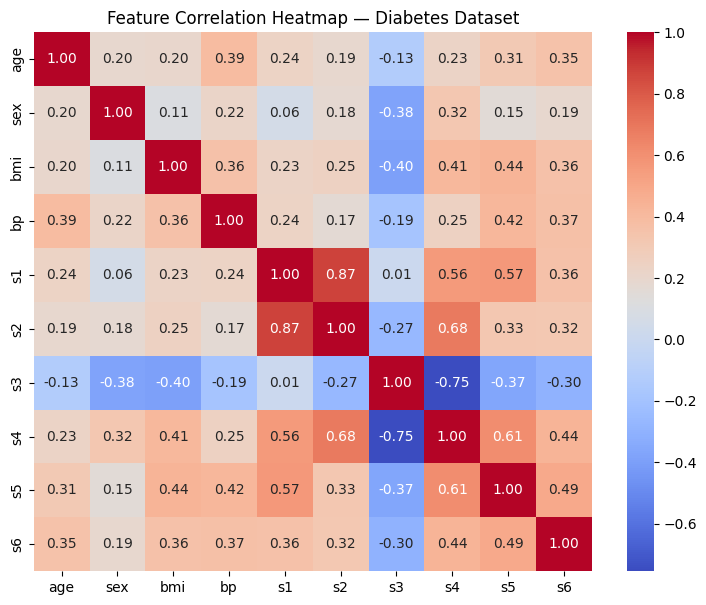

In [8]:
plt.figure(figsize=(9, 7))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap — Diabetes Dataset')
plt.show()

A few features, such as **`s1` and `s2`**, as well as **`s4` and `s5`**, show relatively high correlation with each other. This is important to keep in mind because **Decision Trees are generally not affected by multicollinearity** in the same way as models like **Linear Regression**.

Instead of trying to use all highly correlated features together, a Decision Tree simply selects the feature that provides the **best split** at each node. If two features contain similar information, the tree will typically choose one of them and ignore the other, making Decision Trees naturally robust to correlated features.

# **5. Fit a Default Decision Tree Regressor (Expect Overfitting)**

In [9]:
regressor = DecisionTreeRegressor(random_state=10)
regressor.fit(X_train, y_train)

y_pred_default = regressor.predict(X_test)

r2_default = r2_score(y_test, y_pred_default)
mae_default = mean_absolute_error(y_test, y_pred_default)
mse_default = mean_squared_error(y_test, y_pred_default)

print(f"Default (unpruned) Tree -> R2: {r2_default:.3f} | MAE: {mae_default:.2f} | MSE: {mse_default:.2f}")
print(f"Tree depth: {regressor.get_depth()}, Number of leaves: {regressor.get_n_leaves()}")

Default (unpruned) Tree -> R2: -0.160 | MAE: 67.45 | MSE: 7340.64
Tree depth: 19, Number of leaves: 302


A **Decision Tree Regressor** grows by repeatedly splitting the data to reduce prediction error. By default, it continues splitting until no further useful splits can be made (or another stopping condition is reached). This often produces a **very deep tree with many leaf nodes**.

While such a tree can fit the **training data extremely well**, it may also memorize noise and small variations in the data instead of learning the underlying pattern. This phenomenon is known as **overfitting**.

As a result:

- **Training R² Score** is usually **very high** (often close to **1.0**).
- **Test R² Score** is noticeably lower because the model does not generalize well to unseen data.

To verify whether our model has overfit the training data, let's compare the **training R² Score** and the **testing R² Score**. A large gap between these two scores is a strong indication of overfitting.

In [10]:
# Predict the target values for the training dataset
# This is used to evaluate how well the model has learned
# the training data.
train_predictions = regressor.predict(X_train)

# Calculate the R² Score on the training dataset
# A value close to 1.0 indicates that the model fits
# the training data extremely well.
train_r2_default = r2_score(y_train, train_predictions)

# Display the Training and Testing R² Scores side by side
# Comparing these scores helps identify overfitting.
print(f"Train R² Score: {train_r2_default:.3f}")
print(f"Test R² Score : {r2_default:.3f}")

# Interpretation:
# If the training R² Score is much higher than the testing R² Score,
# the model has likely memorized the training data instead of
# learning general patterns, indicating overfitting.
print("A large gap between the Training and Test R² Scores indicates overfitting.")

Train R² Score: 1.000
Test R² Score : -0.160
A large gap between the Training and Test R² Scores indicates overfitting.


# **6. Hyperparameter Tuning with GridSearchCV**

The performance of a **Decision Tree Regressor** depends heavily on its hyperparameters. Instead of manually trying different values, we can use **GridSearchCV** to automatically evaluate multiple combinations and identify the model that performs best.

In this section, we tune the following hyperparameters together:

- **`criterion`** – The function used to measure the quality of each split.
- **`splitter`** – The strategy used to choose the split at each node.
- **`max_depth`** – The maximum depth of the tree, which helps control model complexity and reduce overfitting.
- **`max_features`** – The number of features considered when searching for the best split.

The models are evaluated using **Negative Mean Squared Error (`neg_mean_squared_error`)**, which is the standard regression scoring metric used by Scikit-learn for optimization.

>  **Why Negative Mean Squared Error?**  
> `GridSearchCV` is designed to **maximize** a scoring metric. Since **Mean Squared Error (MSE)** is an error metric that should be **minimized**, Scikit-learn returns its negative value (`neg_mean_squared_error`). During tuning, the model with the **highest (least negative)** score is selected because it corresponds to the **lowest MSE**.

>  **Version Note:**  
> Older versions of Scikit-learn allowed **`max_features='auto'`** for Decision Trees. In recent versions, this option has been **removed** and will raise an error. We use **`None`** instead, which has the equivalent behavior of considering **all available features** when searching for the best split.

In [11]:
params = {
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
    'splitter': ['best', 'random'],
    'max_depth': [1, 2, 3, 4, 5, 6, 10, 15, 20, 25],
    'max_features': ['sqrt', 'log2', None]  # 'auto' removed in recent sklearn versions
}

reg_model = DecisionTreeRegressor(random_state=10)

grid = GridSearchCV(
    estimator=reg_model, param_grid=params, cv=5,
    scoring='neg_mean_squared_error', n_jobs=-1
)
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=10), n_jobs=-1,
             param_grid={'criterion': ['squared_error', 'friedman_mse',
                                       'absolute_error', 'poisson'],
                         'max_depth': [1, 2, 3, 4, 5, 6, 10, 15, 20, 25],
                         'max_features': ['sqrt', 'log2', None],
                         'splitter': ['best', 'random']},
             scoring='neg_mean_squared_error')

In [12]:
print("Best Parameters:", grid.best_params_)
print("Best CV Score (neg MSE): {:.2f}".format(grid.best_score_))

Best Parameters: {'criterion': 'squared_error', 'max_depth': 4, 'max_features': None, 'splitter': 'random'}
Best CV Score (neg MSE): -4069.50


## **7. Evaluate the Tuned Model**

In [13]:
y_pred_tuned = grid.predict(X_test)

r2_tuned = r2_score(y_test, y_pred_tuned)
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)

print(f"Tuned Tree -> R2: {r2_tuned:.3f} | MAE: {mae_tuned:.2f} | MSE: {mse_tuned:.2f}")

Tuned Tree -> R2: 0.338 | MAE: 51.57 | MSE: 4189.66


# **8. Before vs. After Comparison**

So far, we have trained:

- A **default Decision Tree Regressor**, which is likely to overfit the training data.
- A **tuned Decision Tree Regressor**, whose hyperparameters were optimized using **GridSearchCV**.

Although the tuned model's performance has already been evaluated, it is often more informative to compare the **default** and **tuned** models **side by side**.

This comparison makes it easier to see how hyperparameter tuning affects the model's ability to **generalize to unseen data**.

We will compare both models using the following regression metrics:

- **R² Score** – Measures how well the model explains the variation in the target values. A **higher** value indicates better performance.
- **Mean Absolute Error (MAE)** – Measures the average absolute prediction error. A **lower** value is better.
- **Mean Squared Error (MSE)** – Measures the average squared prediction error. A **lower** value indicates fewer large prediction errors.

By comparing these metrics, we can determine whether hyperparameter tuning has successfully reduced overfitting and improved the model's overall performance on unseen data.

In [14]:
comparison = pd.DataFrame({
    'Model': ['Default (unpruned)', 'GridSearchCV Tuned'],
    'R2 Score': [r2_default, r2_tuned],
    'MAE': [mae_default, mae_tuned],
    'MSE': [mse_default, mse_tuned]
})
comparison

,Model,R2 Score,MAE,MSE
0,Default (unpruned),-0.160085,67.451128,7340.639098
1,GridSearchCV Tuned,0.337883,51.566040,4189.656735


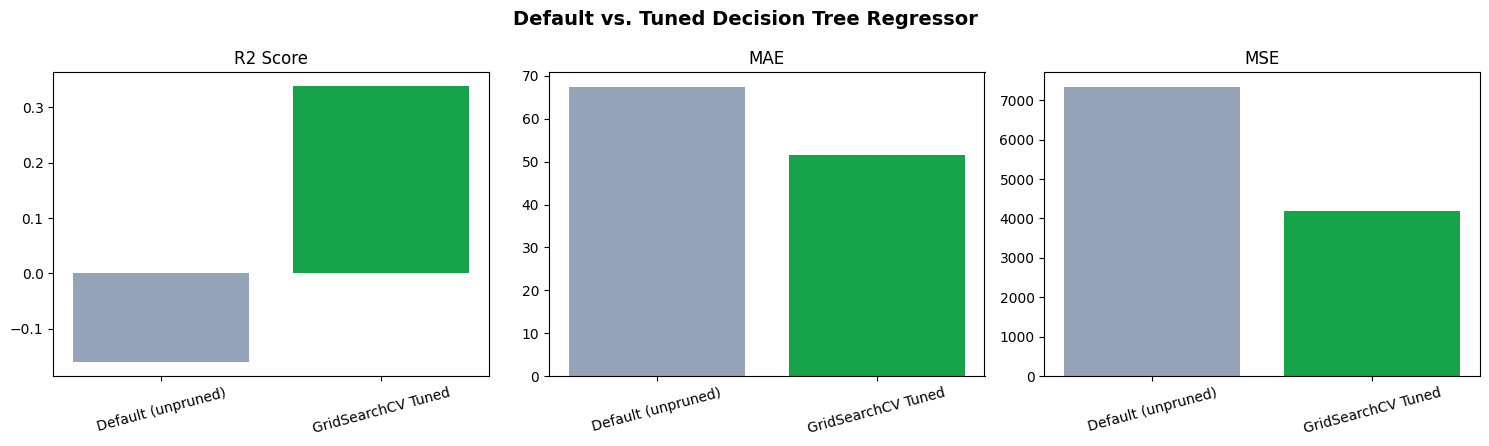

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metrics_to_plot = ['R2 Score', 'MAE', 'MSE']
colors = ['#94a3b8', '#16a34a']

for ax, metric in zip(axes, metrics_to_plot):
    ax.bar(comparison['Model'], comparison[metric], color=colors)
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Default vs. Tuned Decision Tree Regressor', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **Note:**  
> The **R² Score** may **increase, decrease, or remain nearly the same** after hyperparameter tuning. This is completely normal and depends on factors such as the **train-test split**, **cross-validation folds**, and the **best hyperparameters** selected during the GridSearchCV search.
>
> Hyperparameter tuning (or pruning) aims to **reduce overfitting** by creating a simpler model that generalizes better to unseen data. In doing so, the model may sacrifice a small amount of training performance in exchange for improved robustness.
>
> For relatively **small and noisy datasets** like the Diabetes dataset (442 patient records with biological measurements), the improvement in test performance is often **modest rather than dramatic**. Therefore, if the tuned model performs similarly—or only slightly better than the default model—it is an expected and realistic outcome, **not an indication of an error in the implementation**.

## 9. Visualize the Tuned Decision Tree

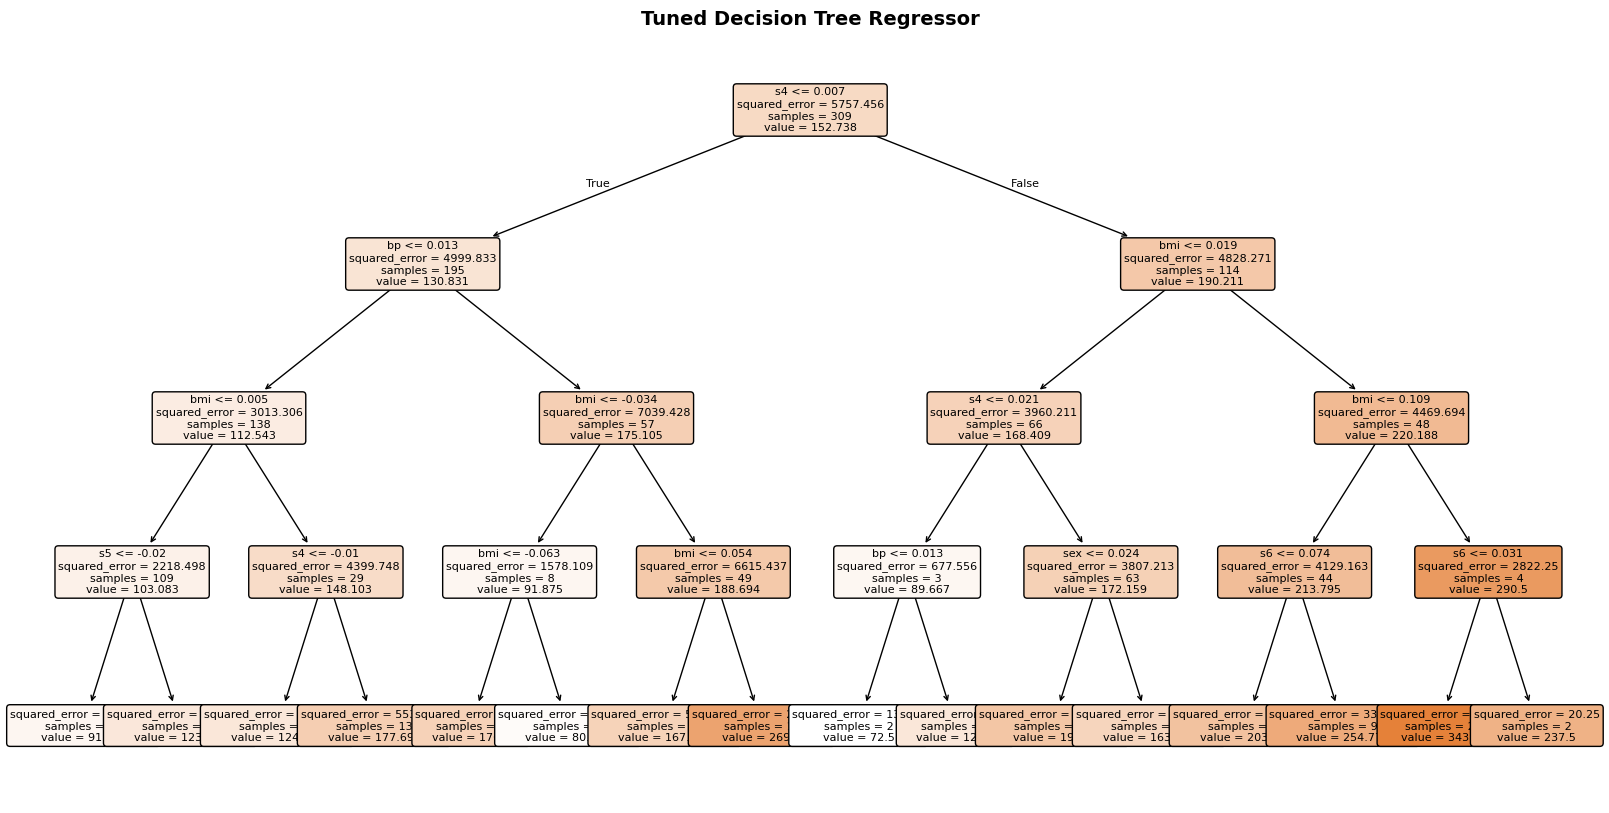

In [16]:
best_model = grid.best_estimator_

plt.figure(figsize=(20, 10))
plot_tree(
    best_model, filled=True, feature_names=X.columns,
    rounded=True, fontsize=8
)
plt.title('Tuned Decision Tree Regressor', fontsize=14, fontweight='bold')
plt.show()

Although the **Decision Tree Regressor** shown here is more difficult to read than the earlier **Iris Decision Tree Classifier**, the interpretation process is exactly the same.

The main difference is that this dataset contains **10 input features** and uses **continuous numerical splits**, resulting in a **larger and deeper tree** with more decision nodes.

Even though the visualization is more complex, each node follows the same structure:

- **Splitting Rule** – The feature and threshold used to divide the data (for example, `bmi <= 0.03`).
- **Criterion Value** – The impurity or error measure (such as **squared error**) after the split.
- **Samples** – The number of training samples that reach that node.
- **Predicted Value** – The average target value (mean) of all training samples in that node. This is the prediction the model makes if a new sample ends up in that leaf node.

Although the complete tree may be difficult to inspect visually, the **same reading rules apply**: start at the **root node**, follow the decision rules based on the feature values, and continue until you reach a **leaf node**, where the displayed **predicted value** becomes the model's final prediction.

## **10. Actual vs. Predicted & Residual Plots**

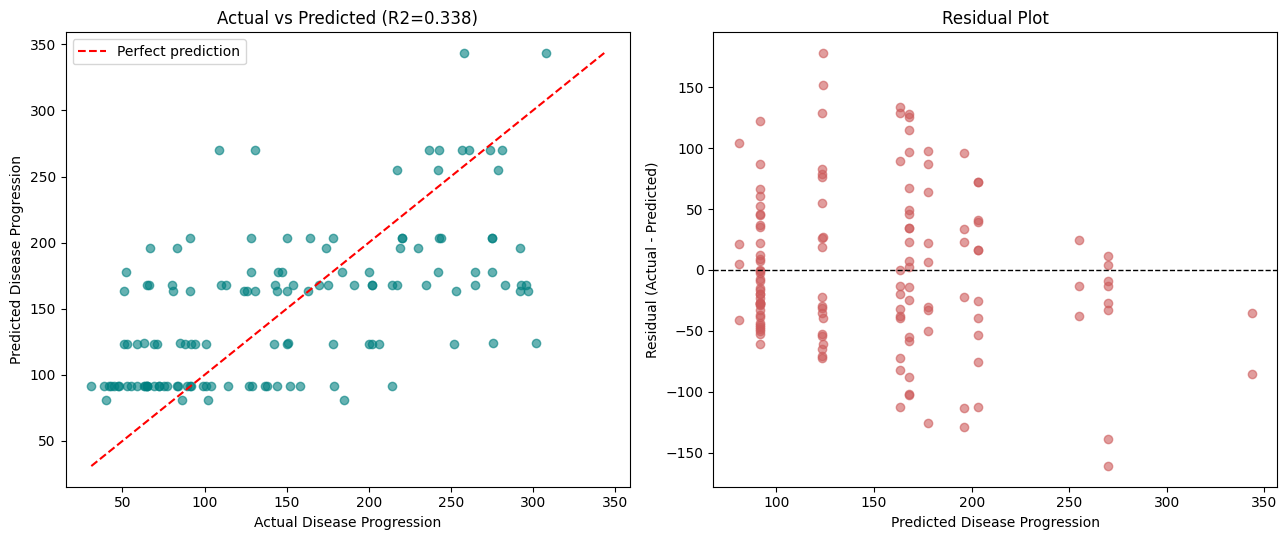

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_tuned, alpha=0.6, color='teal')
lims = [min(y_test.min(), y_pred_tuned.min()), max(y_test.max(), y_pred_tuned.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Disease Progression')
axes[0].set_ylabel('Predicted Disease Progression')
axes[0].set_title(f'Actual vs Predicted (R2={r2_tuned:.3f})')
axes[0].legend()

# Residuals
residuals = y_test - y_pred_tuned
axes[1].scatter(y_pred_tuned, residuals, alpha=0.6, color='indianred')
axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_xlabel('Predicted Disease Progression')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

## **11. Feature Importances**

Which of the 10 health measurements did the tuned tree actually rely on most?

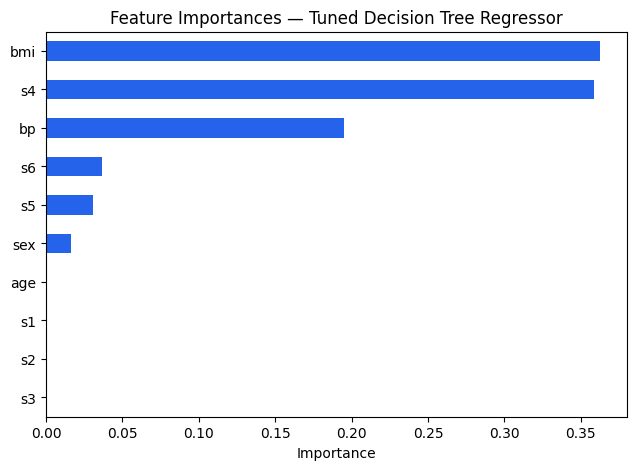

,0
bmi,0.362267
s4,0.358828
bp,0.195002
s6,0.036934
s5,0.030805
sex,0.016164
age,0.000000
s1,0.000000
s2,0.000000
s3,0.000000


In [18]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7.5, 5))
importances.plot(kind='barh', color='#2563eb')
plt.xlabel('Importance')
plt.title('Feature Importances — Tuned Decision Tree Regressor')
plt.gca().invert_yaxis()
plt.show()

importances

`bmi` and `s5` (a blood serum measurement) are commonly the strongest predictors of diabetes progression in this dataset — worth cross-checking against the correlation heatmap from Section 4.

# **12. Cross-Validation**

So far, we have evaluated our models using a **single train-test split**. While this is a common approach, the evaluation can vary depending on **which samples are assigned to the training set and which are assigned to the testing set**.

This is especially important for the **Diabetes dataset**, which contains only **442 samples**. With a relatively small dataset, different train-test splits can produce noticeably different evaluation scores.

To obtain a **more reliable estimate** of model performance, we use **5-Fold Cross-Validation**.

In this section, we compare both:

- **Default Decision Tree Regressor**
- **GridSearchCV Tuned Decision Tree Regressor**

using **5-fold Cross-Validation**.

During 5-fold Cross-Validation:

1. The dataset is divided into **5 equal folds**.
2. The model is trained on **4 folds**.
3. The remaining fold is used for validation.
4. This process is repeated **5 times**, so every sample is used for validation exactly once.
5. The final score is the **average performance across all five folds**.

Compared to a single train-test split, Cross-Validation provides a more stable and reliable estimate of how well the model is expected to perform on unseen data.

In [19]:
cv_default = cross_val_score(DecisionTreeRegressor(random_state=10), X, y, cv=5, scoring='r2')
cv_tuned = cross_val_score(best_model, X, y, cv=5, scoring='r2')

print("Default tree CV R2 scores:", np.round(cv_default, 3))
print(f"Default tree Mean CV R2  : {cv_default.mean():.3f} (+/- {cv_default.std():.3f})")
print()
print("Tuned tree CV R2 scores  :", np.round(cv_tuned, 3))
print(f"Tuned tree Mean CV R2    : {cv_tuned.mean():.3f} (+/- {cv_tuned.std():.3f})")

Default tree CV R2 scores: [-0.214 -0.145 -0.046 -0.039 -0.175]
Default tree Mean CV R2  : -0.124 (+/- 0.070)

Tuned tree CV R2 scores  : [0.149 0.288 0.413 0.312 0.405]
Tuned tree Mean CV R2    : 0.314 (+/- 0.096)


Comparing the **cross-validation scores** of the default and tuned models provides a **more reliable assessment** of whether hyperparameter tuning actually improved the model.

Unlike a **single train-test split**, which can produce results that depend on one particular partition of the data, **5-Fold Cross-Validation** evaluates the model on multiple training and validation splits and reports the average performance.

Because the evaluation is based on several different data splits, the resulting score is generally a **more stable and trustworthy estimate** of how well the model is expected to perform on unseen data.

For this reason, the cross-validation results should be considered a stronger indicator of whether the tuned Decision Tree Regressor truly generalizes better than the default model.

## **Predicting a New Data Point**

Once the Decision Tree Regressor has been trained, it can be used to predict the target value for **new, unseen data**.

The new data point must contain **all 10 input features** in the **same order** used during training:

1. `age`
2. `sex`
3. `bmi`
4. `bp`
5. `s1`
6. `s2`
7. `s3`
8. `s4`
9. `s5`
10. `s6`

The trained model follows the learned decision rules from the **root node** to a **leaf node** based on the feature values. The **predicted value** stored in the final leaf node is returned as the estimated disease progression for that patient.

This demonstrates how a trained Decision Tree Regressor can be applied to make predictions on previously unseen data.

**Using the Best Model from GridSearchCV**

In [20]:
# Create a new data point
# Feature order:
# age, sex, bmi, bp, s1, s2, s3, s4, s5, s6

new_data = [[
    0.03,    # age
   -0.04,    # sex
    0.05,    # bmi
    0.02,    # bp
   -0.01,    # s1
   -0.02,    # s2
    0.03,    # s3
   -0.01,    # s4
    0.04,    # s5
    0.01     # s6
]]

# Predict disease progression
prediction = grid.best_estimator_.predict(new_data)

# Display the prediction
print(f"Predicted Disease Progression: {prediction[0]:.2f}")

Predicted Disease Progression: 167.90
